In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay

In [2]:
train_part1 = pd.read_parquet("ClearData/train_part1.parquet")

In [3]:
train_part1["weights"] = 1
train_part1["weights"] = train_part1["target"].apply(lambda x: 10 if x == 1 else 1)

In [4]:
train_part1

,event_type_nm,event_desc,channel_indicator_type,channel_indicator_sub_type,operaton_amt,currency_iso_cd,mcc_code,pos_cd,developer_tools,phone_voip_call_state,web_rdp_connection,compromised,Hour,target,weights
0,14,75,6,5,56422.0,0.0,4,3.0,-1,-1,-1,-1,5,0,1
1,7,56,4,15,-1.0,-1.0,-1,-1.0,-1,-1,-1,-1,10,0,1
2,3,120,6,5,300870.0,0.0,10,3.0,-1,-1,-1,-1,10,0,1
3,14,75,6,5,298458.0,0.0,1,3.0,-1,-1,-1,-1,7,0,1
4,14,75,6,5,59944.0,0.0,15,3.0,-1,-1,-1,-1,11,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28618589,14,75,0,5,8067.0,0.0,4,-1.0,-1,-1,-1,-1,4,0,1
28618590,14,75,0,5,9005.0,0.0,4,-1.0,-1,-1,-1,-1,8,0,1
28618591,14,75,0,5,7992.0,0.0,4,-1.0,-1,-1,-1,-1,8,0,1
28618592,14,75,0,5,40849.0,0.0,4,-1.0,-1,-1,-1,-1,12,0,1


In [5]:
x = train_part1.drop(columns="target")
y = train_part1["target"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y)    # Можно сделать проще!

train_weights = X_train["weights"]
test_weights = X_test["weights"]
X_train.drop(columns="weights", inplace=True)
X_test.drop(columns="weights", inplace=True)

In [7]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [8]:
rfc = RandomForestClassifier(n_estimators=5, max_depth=5, class_weight="balanced")

Train metrics:
Accuracy: 0.8545414570030502
Precision: 0.0019479463663297897
Recall: 0.46631726958967146
F1-score: 0.0038796861261605224

Test metrics:
Accuracy: 0.8546714374567589
Precision: 0.0018881902718512924
Recall: 0.451668584579977
F1-score: 0.0037606591932547668

Confusion matrix


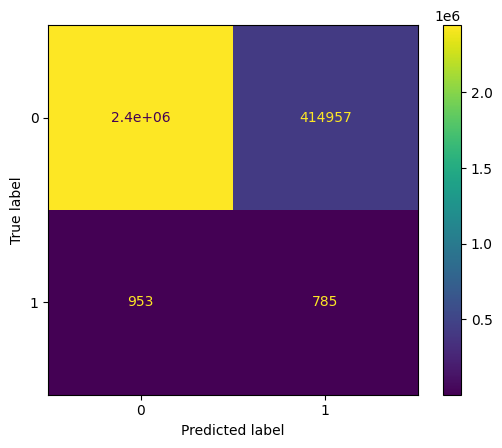

In [9]:
train_models(rfc, X_train, X_test, y_train, y_test)

In [10]:
rfc2 = RandomForestClassifier(n_estimators=10, max_depth=5, class_weight="balanced")

Train metrics:
Accuracy: 0.8807681905632911
Precision: 0.002313023036406331
Recall: 0.4537901060974051
F1-score: 0.004602586134806507

Test metrics:
Accuracy: 0.8807901155192777
Precision: 0.0022437044293365086
Recall: 0.44016110471806674
F1-score: 0.004464650473311312

Confusion matrix


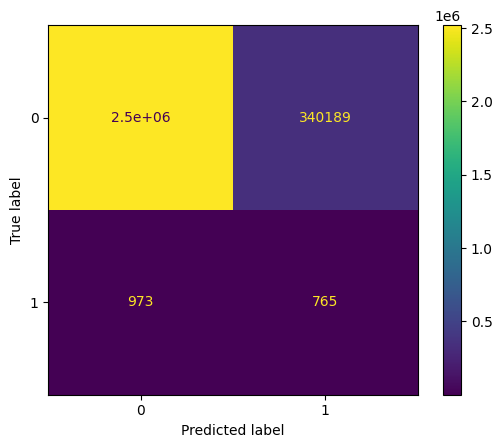

In [11]:
train_models(rfc2, X_train, X_test, y_train, y_test)

In [12]:
Gb = GradientBoostingClassifier(n_estimators=5, max_depth=5)

Train metrics:
Accuracy: 0.9993741442529165
Precision: 0.10631229235880399
Recall: 0.00409050236482168
F1-score: 0.007877892663712457

Test metrics:
Accuracy: 0.9993748820697029
Precision: 0.13043478260869565
Recall: 0.005178365937859608
F1-score: 0.00996126175982291

Confusion matrix


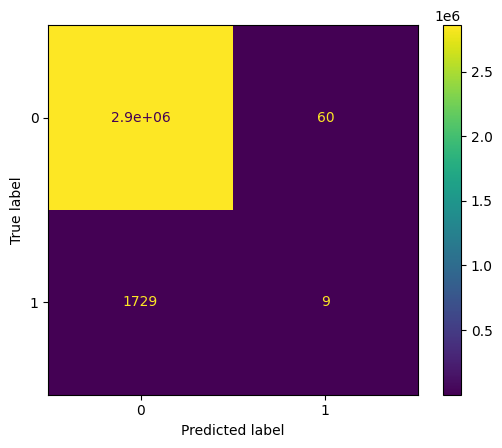

In [13]:
train_models(Gb, X_train, X_test, y_train, y_test)

In [14]:
Gb2 = GradientBoostingClassifier(n_estimators=5, max_depth=5)

Train metrics:
Accuracy: 0.9993652145493291
Precision: 0.09540229885057472
Recall: 0.0053048702543781155
F1-score: 0.010050859772341972

Test metrics:
Accuracy: 0.9993612545687071
Precision: 0.09090909090909091
Recall: 0.005753739930955121
F1-score: 0.010822510822510822

Confusion matrix


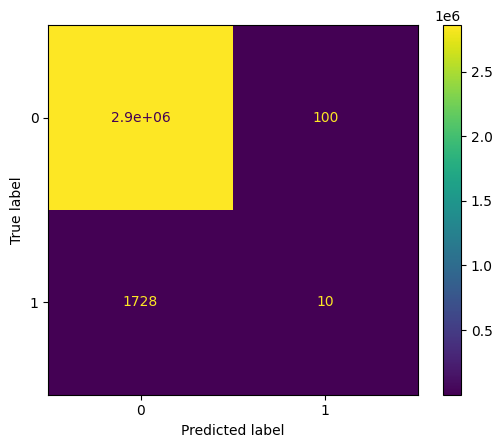

In [15]:
train_models(Gb2, X_train, X_test, y_train, y_test, sample_weight=train_weights)

In [16]:
Gb2_long = GradientBoostingClassifier(n_estimators=15, max_depth=5)

Train metrics:
Accuracy: 0.9993649039509435
Precision: 0.10444444444444445
Recall: 0.0060079253483318424
F1-score: 0.01136226278254563

Test metrics:
Accuracy: 0.9993616039918095
Precision: 0.08411214953271028
Recall: 0.005178365937859608
F1-score: 0.00975609756097561

Confusion matrix


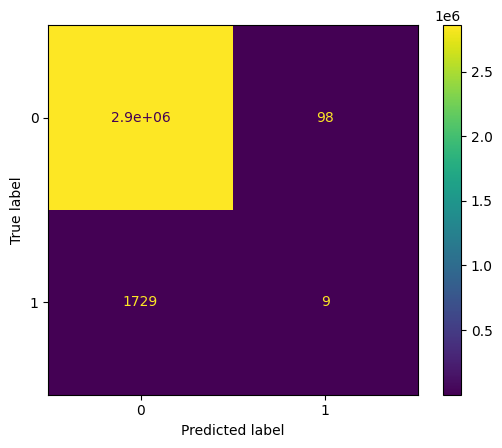

In [17]:
train_models(Gb2_long, X_train, X_test, y_train, y_test, sample_weight=train_weights)

In [18]:
Gb3 = GradientBoostingClassifier(n_estimators=5, max_depth=7)

Train metrics:
Accuracy: 0.9992413634430515
Precision: 0.07019867549668875
Recall: 0.020324683625207722
F1-score: 0.031522601110229975

Test metrics:
Accuracy: 0.9992330162901051
Precision: 0.05458089668615984
Recall: 0.01611047180667434
F1-score: 0.024877832074633496

Confusion matrix


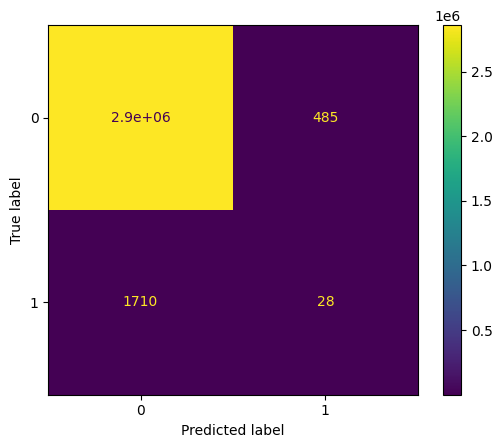

In [19]:
train_models(Gb3, X_train, X_test, y_train, y_test, sample_weight=train_weights)

Увеличим веса и повторим обучение

In [20]:
train_weights.value_counts()

weights
1     25741088
10       15646
Name: count, dtype: int64

In [21]:
train_weights = train_weights.apply(lambda x: 20 if x == 10 else 1)

In [22]:
train_weights.value_counts()

weights
1     25741088
20       15646
Name: count, dtype: int64

Train metrics:
Accuracy: 0.9993020854274459
Precision: 0.08570412517780938
Recall: 0.015403297967531638
F1-score: 0.026113338389858055

Test metrics:
Accuracy: 0.9993008043719819
Precision: 0.06885245901639345
Recall: 0.012082853855005753
F1-score: 0.020558002936857563

Confusion matrix


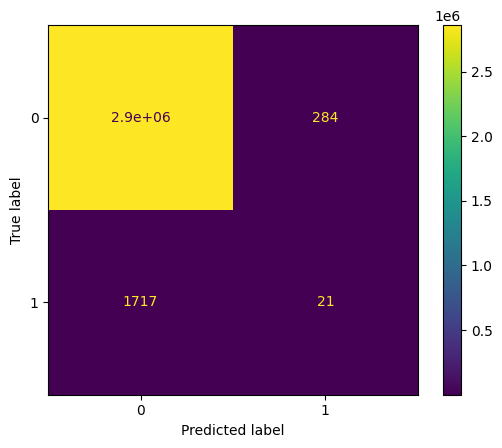

In [23]:
train_models(Gb3, X_train, X_test, y_train, y_test, sample_weight=train_weights)    # С тем же Gb3